# Phase 2: Data Understanding

**CRISP-DM Phase Description:**  
This phase involves acquiring the data, getting familiar with it, identifying data quality problems, and detecting initial insights. A thorough understanding of the data at this stage is critical for a successful project.

---

In [1]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
%matplotlib inline

---
### Task 1: Collect Initial Data

Acquire the necessary data and load it into the analysis environment. This task includes:

- **Data Acquisition:** Load data from files, databases, APIs, or other sources.
- **Initial Data Report:** Document the data source(s), the method of acquisition, and any problems encountered during loading.

**Instructions:**
1. Update the file path(s) below to point to your actual dataset(s).
2. Load the data into a Pandas DataFrame.
3. Display a small sample of the data to confirm it loaded correctly.

In [2]:
# Load your dataset(s) here.
DATA_PATH = '../EV_Predictive_Maintenance_Dataset_15min.csv'

df = pd.read_csv(DATA_PATH)
df.head()

,Timestamp,SoC,SoH,Battery_Voltage,Battery_Current,Battery_Temperature,Charge_Cycles,Motor_Temperature,Motor_Vibration,Motor_Torque,Motor_RPM,Power_Consumption,Brake_Pad_Wear,Brake_Pressure,Reg_Brake_Efficiency,Tire_Pressure,Tire_Temperature,Suspension_Load,Ambient_Temperature,Ambient_Humidity,Load_Weight,Driving_Speed,Distance_Traveled,Idle_Time,Route_Roughness,RUL,Failure_Probability,Maintenance_Type,TTF,Component_Health_Score
0,2020-01-01 00:00:00,0.826099,0.941338,210.163881,-22.753095,27.149201,149.190930,48.496049,0.369095,113.435589,1996.008632,28.491339,0.237134,46.246011,0.810858,24.318716,26.699988,187.132154,13.213039,94.621365,741.754518,103.421162,66.232383,0.520922,0.225970,260.503381,0,1,111.116697,0.852745
1,2020-01-01 00:15:00,0.064728,0.916059,364.000102,-27.701120,53.655101,171.702388,57.829492,1.449195,105.587160,1798.361835,25.450963,0.126469,35.790875,0.889325,24.266465,27.214893,101.420835,-6.713220,41.033266,769.134035,46.041935,3.146238,0.844005,0.204350,212.813954,0,2,179.229425,0.827616
2,2020-01-01 00:30:00,0.873643,0.908020,388.855089,-36.646406,29.559090,191.617645,46.518363,1.859045,119.610302,1881.417071,22.618821,0.199936,30.896217,0.913198,33.387677,33.147433,175.720864,24.078900,34.406233,917.262931,59.588422,79.909148,0.992405,0.175125,273.394511,0,1,171.852663,0.876887
3,2020-01-01 00:45:00,0.853009,0.916476,370.570602,-37.609429,29.690283,111.881817,54.163681,0.381500,182.535625,1593.549698,20.838012,0.138880,43.541937,0.899215,32.261760,32.924688,129.309498,11.949569,44.478083,600.598736,44.222285,0.774000,0.007615,0.213264,229.508442,0,0,165.221328,0.816290
4,2020-01-01 01:00:00,0.947540,0.913206,390.011904,-14.275808,28.864338,163.774377,42.075978,0.433927,173.298044,1585.970891,23.663755,0.249649,48.761583,0.471733,33.083867,26.806491,165.171360,18.953288,42.783036,613.153029,41.374684,2.872124,0.771938,0.770257,257.302631,1,0,176.890659,0.744260


In [3]:
# Verify the data loaded correctly by displaying shape and a sample
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.sample(5)

Dataset shape: 175393 rows x 30 columns


,Timestamp,SoC,SoH,Battery_Voltage,Battery_Current,Battery_Temperature,Charge_Cycles,Motor_Temperature,Motor_Vibration,Motor_Torque,Motor_RPM,Power_Consumption,Brake_Pad_Wear,Brake_Pressure,Reg_Brake_Efficiency,Tire_Pressure,Tire_Temperature,Suspension_Load,Ambient_Temperature,Ambient_Humidity,Load_Weight,Driving_Speed,Distance_Traveled,Idle_Time,Route_Roughness,RUL,Failure_Probability,Maintenance_Type,TTF,Component_Health_Score
143084,2024-01-30 11:00:00,0.835202,0.908106,242.150378,-43.471516,29.600385,581.914299,58.716722,0.411102,131.752298,1910.609088,23.883943,0.235016,44.968646,0.936294,30.447415,32.114357,458.690599,11.091474,34.434331,834.683442,44.017693,80.063691,0.042074,0.259204,200.048612,0,0,193.432468,0.740114
15014,2020-06-05 09:30:00,0.091951,0.431571,239.513532,-32.851943,33.155794,182.035066,41.356445,0.235559,160.723137,1805.383075,78.936415,0.205292,32.850967,0.819052,30.087305,34.555387,196.776940,14.343103,32.495342,609.990099,46.206029,65.699034,0.060552,0.172649,265.414874,0,0,112.837066,0.869385
27152,2020-10-09 20:00:00,0.966069,0.952653,391.513693,-48.158360,29.554726,147.284517,80.400975,0.381643,359.012065,1829.192585,24.036541,0.742849,45.925025,0.834247,23.994578,29.200777,137.977400,23.439450,33.584806,1825.723262,43.303666,1.201732,0.232052,0.951367,211.818436,0,0,10.095024,0.984643
164270,2024-09-07 03:30:00,0.912696,0.908871,384.308114,-197.591085,25.870056,166.240896,48.176271,0.429030,112.768051,4192.518200,24.236396,0.126905,76.123122,0.892133,31.972817,32.283513,111.350236,23.491035,35.596230,639.681936,54.592050,0.072872,0.065266,0.145117,229.857784,0,0,135.746898,0.757553
5877,2020-03-02 05:15:00,0.948093,0.589324,392.187813,-16.789640,31.092194,699.581735,45.889338,0.435552,348.838758,1677.659251,23.352160,0.253129,70.745070,0.900242,30.144710,47.415668,435.130279,19.587919,31.335641,503.599850,57.434501,71.563171,0.011696,0.288681,203.992702,0,1,188.816602,0.807528


In [4]:
# Document data source details
data_source_report = {
    "source": "Local CSV file",
    "acquisition_method": "Direct Load",
    "date_acquired": "Phase 2 execution time",
    "issues_encountered": ["No initial issues. The 92MB file loaded successfully."]
}
print(data_source_report)

{'source': 'Local CSV file', 'acquisition_method': 'Direct Load', 'date_acquired': 'Phase 2 execution time', 'issues_encountered': ['No initial issues. The 92MB file loaded successfully.']}


---
### Task 2: Describe Data

Examine the "surface" properties of the acquired data. This includes:

- **Volume:** How many records (rows) and attributes (columns) does the dataset contain?
- **Field Identities:** What are the names, data types, and roles (ID, feature, target) of each column?
- **Descriptive Statistics:** What are the basic statistics (mean, median, std, min, max) of the numerical features and frequency counts for categorical features?

**Instructions:** Use Pandas built-in methods (`.info()`, `.describe()`, `.dtypes`, `.value_counts()`) to generate a comprehensive description of your data.

In [5]:
# Describe the structure and schema of your data.
# Inspect data types, non-null counts, and memory usage.

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 175393 entries, 0 to 175392
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Timestamp               175393 non-null  str    
 1   SoC                     175393 non-null  float64
 2   SoH                     175393 non-null  float64
 3   Battery_Voltage         175393 non-null  float64
 4   Battery_Current         175393 non-null  float64
 5   Battery_Temperature     175393 non-null  float64
 6   Charge_Cycles           175393 non-null  float64
 7   Motor_Temperature       175393 non-null  float64
 8   Motor_Vibration         175393 non-null  float64
 9   Motor_Torque            175393 non-null  float64
 10  Motor_RPM               175393 non-null  float64
 11  Power_Consumption       175393 non-null  float64
 12  Brake_Pad_Wear          175393 non-null  float64
 13  Brake_Pressure          175393 non-null  float64
 14  Reg_Brake_Efficiency    175393 

In [6]:
# Generate descriptive statistics for numerical columns
df.describe()

,SoC,SoH,Battery_Voltage,Battery_Current,Battery_Temperature,Charge_Cycles,Motor_Temperature,Motor_Vibration,Motor_Torque,Motor_RPM,Power_Consumption,Brake_Pad_Wear,Brake_Pressure,Reg_Brake_Efficiency,Tire_Pressure,Tire_Temperature,Suspension_Load,Ambient_Temperature,Ambient_Humidity,Load_Weight,Driving_Speed,Distance_Traveled,Idle_Time,Route_Roughness,RUL,Failure_Probability,Maintenance_Type,TTF,Component_Health_Score
count,175393.000000,175393.000000,175393.000000,175393.000000,175393.000000,175393.000000,175393.000000,175393.000000,175393.000000,175393.000000,175393.000000,175393.000000,175393.000000,175393.000000,175393.000000,175393.000000,175393.000000,175393.000000,175393.000000,175393.000000,175393.000000,175393.000000,175393.000000,175393.000000,175393.000000,175393.000000,175393.000000,175393.000000,175393.000000
mean,0.779882,0.882219,352.713482,-47.892493,33.399346,217.685124,56.027332,0.523942,179.786407,2235.503735,31.702128,0.297660,46.036323,0.818935,31.002062,32.996770,195.386418,14.106543,47.114699,899.622755,58.254410,15.426523,1.554246,0.297452,216.366252,0.098818,0.498418,129.723870,0.744438
std,0.291660,0.164805,55.246513,45.358339,8.655192,164.506573,15.447305,0.434352,76.767046,1188.119583,16.398066,0.240742,15.434657,0.141306,3.849333,7.706355,111.369775,9.048807,17.850439,384.992691,20.599544,25.663043,2.581281,0.240178,84.594382,0.298418,0.865544,55.178580,0.265023
min,0.000006,0.400001,200.001095,-199.994036,25.000010,100.000809,40.000182,0.200000,100.000039,1500.005873,20.000007,0.100001,30.000025,0.400009,20.000002,25.000019,100.000476,-9.999705,30.000049,500.001439,40.000040,0.000059,0.000005,0.100000,0.000148,0.000000,0.000000,0.000009,0.000005
25%,0.823508,0.911699,355.989733,-45.270093,27.948170,129.489301,45.872695,0.288583,129.469691,1646.972583,22.922685,0.158785,35.903621,0.817805,30.589513,27.937134,129.281059,11.744867,35.864228,647.083997,45.906363,2.937620,0.293588,0.159248,211.700417,0.000000,0.000000,111.816152,0.735163
50%,0.882380,0.941193,370.587405,-33.518350,30.887664,158.901349,51.757365,0.376488,158.810055,1793.947006,25.875666,0.217182,41.759191,0.861823,32.061660,30.883562,159.016855,16.183969,41.761493,793.026812,51.776604,5.881970,0.586629,0.217891,241.127447,0.000000,0.000000,141.216309,0.823212
75%,0.941148,0.970720,385.262527,-21.757595,33.826187,188.312590,57.678209,0.465118,188.025425,1941.249131,28.809528,0.276474,47.668778,0.905818,33.535032,33.817042,188.383994,20.579419,47.652206,940.973233,57.669053,8.790443,0.882060,0.276479,270.516993,0.000000,1.000000,170.507963,0.911802
max,0.999999,0.999999,399.999314,-10.000173,59.997570,699.996920,99.999997,1.999954,399.998498,5999.999833,79.999908,0.999992,89.999940,0.950000,34.999976,54.999778,499.989364,24.999959,94.998590,1999.971806,119.998280,99.999640,9.999459,0.999997,299.999891,1.000000,3.000000,199.998920,0.999999


In [7]:
# Generate descriptive statistics for categorical columns
df.describe(include='object')


C:\Users\hp\AppData\Local\Temp\ipykernel_44556\2712043452.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Timestamp
count,175393
unique,175393
top,2020-01-01 00:00:00
freq,1


---
### Task 3: Explore Data

Dig deeper into the data using querying, visualisation, and statistical analysis to find initial insights, patterns, and interesting subsets. Key activities include:

- **Univariate Analysis:** Examine the distribution of individual features using histograms, box plots, and bar charts.
- **Bivariate / Multivariate Analysis:** Explore relationships between features using scatter plots, correlation matrices, and grouped summaries.
- **Initial Hypotheses:** Formulate initial hypotheses based on observed patterns.

**Instructions:** Create visualisations and run queries to understand the distributions, relationships, and patterns in your data.

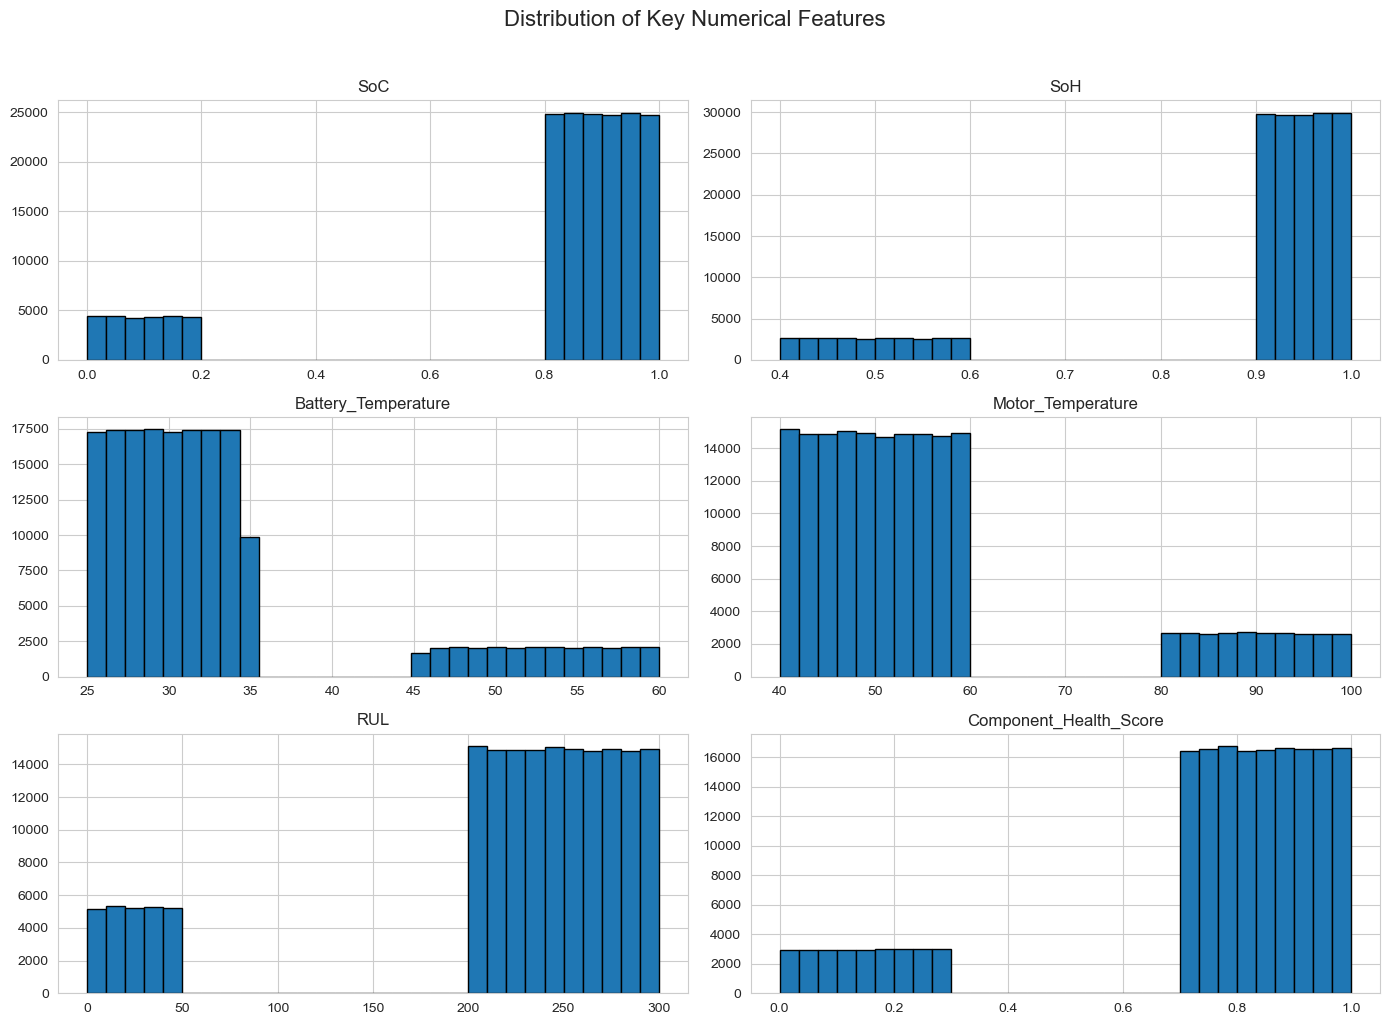

In [8]:
# Perform univariate analysis — explore distributions of individual features.

critical_features = ['SoC', 'SoH', 'Battery_Temperature', 'Motor_Temperature', 'RUL', 'Component_Health_Score']

df[critical_features].hist(figsize=(14, 10), bins=30, edgecolor='black')
plt.suptitle('Distribution of Key Numerical Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

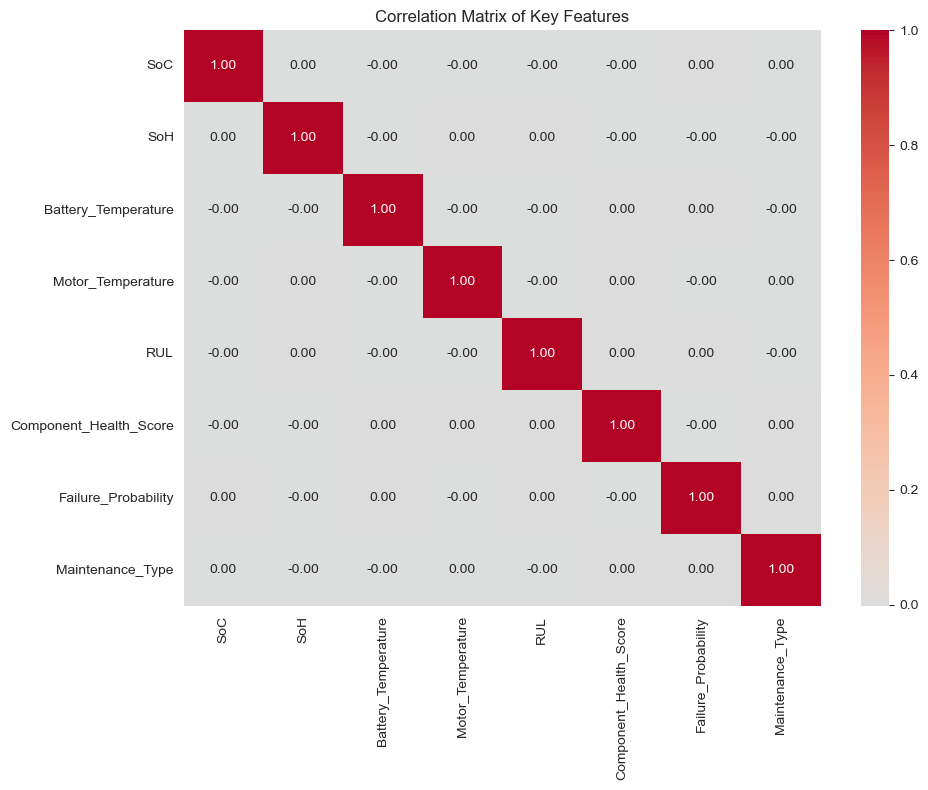

In [9]:
# Perform bivariate/multivariate analysis — explore relationships between features.

target_cols = ['Failure_Probability', 'Maintenance_Type']
features_subset = critical_features + target_cols

plt.figure(figsize=(10, 8))
correlation_matrix = df[features_subset].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Key Features')
plt.tight_layout()
plt.show()

In [10]:
# Document any initial insights or hypotheses from your exploration.

initial_insights = [
    "Insight 1: The dataset contains 175,393 records with 30 attributes.",
    "Insight 2: No missing values are present in the dataset.",
    "Insight 3: The target variables 'Failure_Probability' and 'Maintenance_Type' are already encoded numerically.",
    "Hypothesis 1: Battery and Motor temperatures might show strong relationships with failure probability.",
    "Hypothesis 2: Component_Health_Score and RUL will likely be highly predictive of impending failures based on the business understanding in Phase 1."
]
for i, insight in enumerate(initial_insights, 1):
    print(f"{i}. {insight}")

1. Insight 1: The dataset contains 175,393 records with 30 attributes.
2. Insight 2: No missing values are present in the dataset.
3. Insight 3: The target variables 'Failure_Probability' and 'Maintenance_Type' are already encoded numerically.
4. Hypothesis 1: Battery and Motor temperatures might show strong relationships with failure probability.
5. Hypothesis 2: Component_Health_Score and RUL will likely be highly predictive of impending failures based on the business understanding in Phase 1.


---
### Task 4: Verify Data Quality

Evaluate the completeness and correctness of the data. Check for problems that could affect the analysis:

- **Missing Values:** Identify columns with missing data, the volume, and patterns of missingness.
- **Duplicates:** Check for and report duplicate records.
- **Outliers:** Detect anomalous values using statistical methods or visualisations (box plots, z-scores).
- **Inconsistencies:** Look for data type mismatches, inconsistent formatting, or invalid entries.

**Instructions:** Systematically check for data quality issues and document your findings.

In [11]:
# Check for missing values.

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print("=== Missing Values Report ===")
print(missing_report if len(missing_report) > 0 else "No missing values found.")
print(f"\nTotal columns with missing values: {len(missing_report)}")

=== Missing Values Report ===
No missing values found.

Total columns with missing values: 0


In [12]:
# Check for duplicate records.

duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    print("\nSample of duplicate rows:")
    print(df[df.duplicated(keep=False)].head(10))

Number of duplicate rows: 0


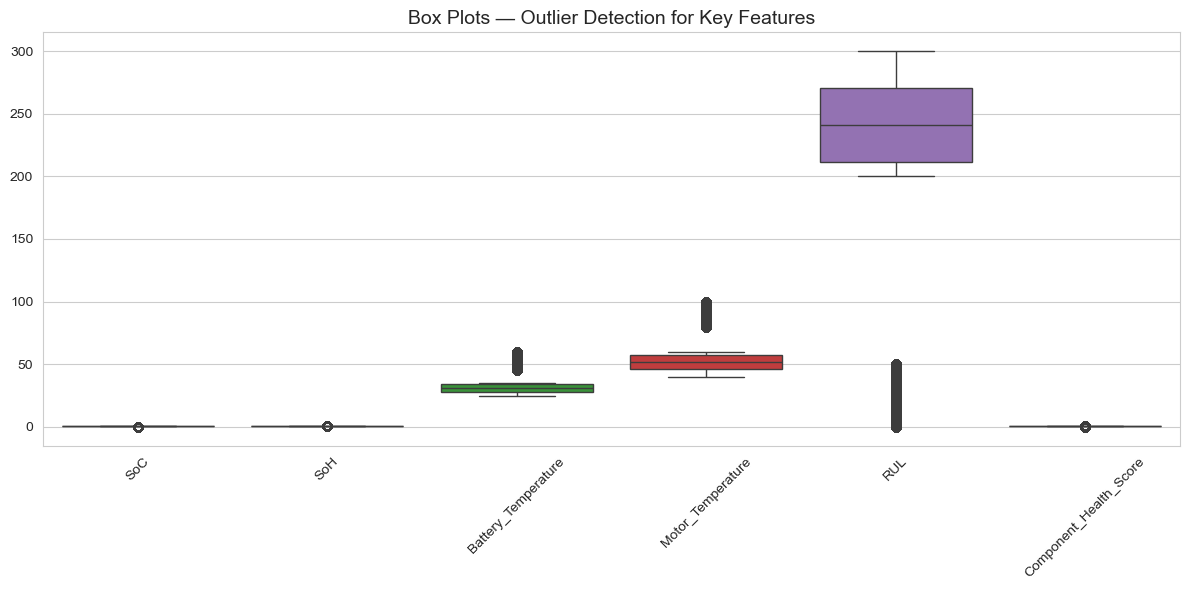

In [13]:
# Detect outliers using box plots or statistical methods.

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[critical_features])
plt.title('Box Plots — Outlier Detection for Key Features', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()